# AICE1006 – Data Analytics  

## Lecture 8 - Feature Engineering


**Zhiwu Huang**  <br/>
Lecturer (Assistant Professor) <br/>
Vision, Learning and Control (VLC) Research Group <br/>
School of Electronics and Computer Science (ECS) <br/>
University of Southampton<br/>

*Office Hour: Wed 2PM-3PM, Please book in advance.* <br/>
``Zhiwu.Huang@soton.ac.uk``


<br/>
<br/>
<!-- <br/> -->

Credit: Jake VanderPlas, Software Engineer, Google Research


## What is feature engineering?

**Feature engineering** means turning raw data into a representation that a model can use.

Most models do not directly understand:
- categories like `"London"`
- free text like `"great course"`
- images as meaningful objects

They understand:
> **numbers arranged as features**

## Why do we do it?

Because the same raw information can be represented in different ways, and some representations are much more useful for learning than others.

Examples:
- numbers → scaling, ratios, polynomial terms
- category → one-hot encoding
- text → word counts, TF-IDF, embeddings
- image → pixels or extracted features

## Big idea for today

> **AI is about representation.**

- In **classical machine learning**, we often design features manually.
- In **modern AI**, models often learn useful representations automatically.

But in both cases, the model still works with **numbers**.

In [161]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")
np.random.seed(20)

# 1. Motivation: does modern AI still need feature engineering?

A good question is:

> “ChatGPT seems to understand language directly. Do we still need feature engineering?”

It looks that way from the outside, because we communicate using natural language.

But internally, the model does **not** work directly with words.  
It converts language into:
- tokens
- token IDs
- vectors (embeddings)

So the main principle is still the same:

> raw data → numerical representation → learning

## Human view vs model view

In [162]:
sentence = "This course is great!"
print("Human view:")
print(sentence)

Human view:
This course is great!


In [163]:
def simple_tokenize(text):
    return re.findall(r"[A-Za-z']+", text.lower())

tokens = simple_tokenize(sentence)
print("Tokens:")
print(tokens)

Tokens:
['this', 'course', 'is', 'great']


In [164]:
vocab = {"this": 101, "course": 205, "is": 17, "great": 999}
token_ids = [vocab[t] for t in tokens]

pd.DataFrame({
    "token": tokens,
    "token_id": token_ids
})

,token,token_id
0,this,101
1,course,205
2,is,17
3,great,999


In [165]:
toy_embeddings = {
    "this":   np.array([ 0.10, -0.20,  0.30,  0.00,  0.40, -0.10]),
    "course": np.array([ 0.50,  0.20, -0.10,  0.30,  0.10,  0.00]),
    "is":     np.array([ 0.05, -0.05,  0.02,  0.01, -0.03,  0.00]),
    "great":  np.array([ 0.80,  0.60,  0.20,  0.50,  0.40,  0.30]),
}

embedding_df = pd.DataFrame(
    [toy_embeddings[t] for t in tokens],
    index=tokens,
    columns=[f"d{i+1}" for i in range(6)]
)
embedding_df

,d1,d2,d3,d4,d5,d6
this,0.10,-0.20,0.30,0.00,0.40,-0.1
course,0.50,0.20,-0.10,0.30,0.10,0.0
is,0.05,-0.05,0.02,0.01,-0.03,0.0
great,0.80,0.60,0.20,0.50,0.40,0.3


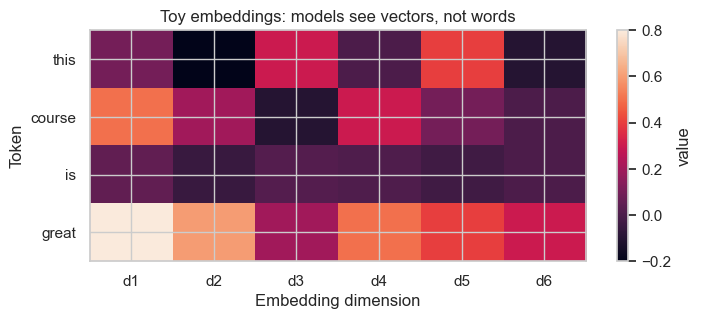

In [166]:
plt.figure(figsize=(8, 3))
plt.imshow(embedding_df.values, aspect="auto")
plt.colorbar(label="value")
plt.xticks(range(embedding_df.shape[1]), embedding_df.columns)
plt.yticks(range(len(tokens)), tokens)
plt.title("Toy embeddings: models see vectors, not words")
plt.xlabel("Embedding dimension")
plt.ylabel("Token")
plt.show()

### Teaching takeaway

Humans see words.  
Models see vectors.

So feature engineering has **not disappeared** in modern AI.

The difference is:
- in classical ML, we manually create many useful features
- in modern AI, the model learns richer representations automatically

# Numerical features: feature engineering can improve representation

We start with the **iris** dataset.

This dataset is already numerical, so it is much easier than real-world data.  
Even so, we can still create **new features** from the existing ones.

In [167]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris["species"] = iris.target

display(df_iris.head())

# Add noise (simulate real-world measurement errors)
np.random.seed(0)
df_iris_drop = df_iris.drop(columns="species")
df_iris_drop_noisy = df_iris_drop + np.random.normal(0, 0.5, df_iris_drop.shape)

df_iris_drop_noisy.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.982026,3.700079,1.889369,1.320447
1,5.833779,2.511361,1.875044,0.124321
2,4.648391,3.405299,1.372022,0.927137
3,4.980519,3.160838,1.721932,0.366837
4,5.747040,3.497421,1.556534,-0.227048


## Baseline model: original features only

In [168]:
X = df_iris_drop_noisy
y = df_iris["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=20, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_base = RandomForestClassifier(random_state=20)
model_base.fit(X_train_scaled, y_train)
y_pred_base = model_base.predict(X_test_scaled)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"Accuracy with original features only: {acc_base:.4f}")

Accuracy with original features only: 0.8667


## Add derived features

A simple idea is to create **polynomial features**:
- original feature
- squared feature
- interaction feature

This gives the model a richer representation of the same data.

In [169]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_feature_names = poly.get_feature_names_out(X.columns)

pd.DataFrame({
    "Generated feature": poly_feature_names
}).head(15)

,Generated feature
0,sepal length (cm)
1,sepal width (cm)
2,petal length (cm)
3,petal width (cm)
4,sepal length (cm)^2
5,sepal length (cm) sepal width (cm)
6,sepal length (cm) petal length (cm)
7,sepal length (cm) petal width (cm)
8,sepal width (cm)^2
9,sepal width (cm) petal length (cm)


In [170]:
model_fe = RandomForestClassifier(random_state=20)
model_fe.fit(X_train_poly, y_train)
y_pred_fe = model_fe.predict(X_test_poly)
acc_fe = accuracy_score(y_test, y_pred_fe)

print(f"Accuracy with engineered features: {acc_fe:.4f}")

Accuracy with engineered features: 0.9111


The exact improvement may be small here, because iris is already a simple dataset and Random Forest is quite strong.

But conceptually, this is important:

> a better representation can make learning easier

## A simpler visual explanation of engineered features

The old “top feature importances” plot can look confusing, because derived features may contain the same variable names multiple times.

For teaching, it is clearer to group features into:
- **original**
- **squared**
- **interaction**

In [171]:
df_imp = pd.DataFrame({
    "feature": poly_feature_names,
    "importance": model_fe.feature_importances_
})

def feature_type(name):
    if "^2" in name:
        return "Squared"
    elif " " in name:
        return "Interaction"
    else:
        return "Original"

df_imp["type"] = df_imp["feature"].apply(feature_type)
df_imp = df_imp.sort_values("importance", ascending=False)

display(df_imp.head(12))

,feature,importance,type
2,petal length (cm),0.295742,Interaction
11,petal length (cm)^2,0.146633,Squared
3,petal width (cm),0.128376,Interaction
12,petal length (cm) petal width (cm),0.094842,Interaction
0,sepal length (cm),0.058939,Interaction
6,sepal length (cm) petal length (cm),0.049768,Interaction
1,sepal width (cm),0.042656,Interaction
9,sepal width (cm) petal length (cm),0.042277,Interaction
13,petal width (cm)^2,0.035750,Squared
7,sepal length (cm) petal width (cm),0.024947,Interaction


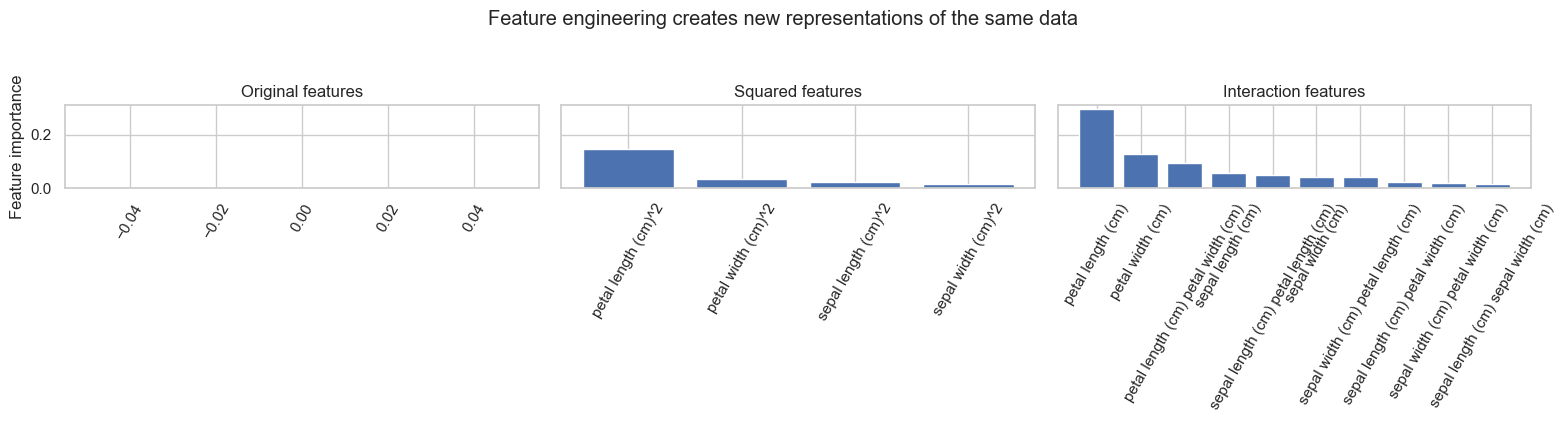

In [172]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, kind in zip(axes, ["Original", "Squared", "Interaction"]):
    subset = df_imp[df_imp["type"] == kind].sort_values("importance", ascending=False)
    ax.bar(subset["feature"], subset["importance"])
    ax.set_title(f"{kind} features")
    ax.tick_params(axis="x", rotation=60)

axes[0].set_ylabel("Feature importance")
plt.suptitle("Feature engineering creates new representations of the same data", y=1.05)
plt.tight_layout()
plt.show()

### What students should notice

The same raw idea can appear in multiple forms:
- `petal width` → original feature
- `petal width^2` → nonlinear version
- `petal length petal width` → interaction with another feature

So the model is really choosing between **different representations of the same information**.

# Categorical features

A common real-world feature type is **categorical data**.

For example, in a housing dataset, we may have:
- price
- number of rooms
- neighbourhood

The neighbourhood is a category, not a quantity.

In [173]:
data = [
    {"price": 850000, "rooms": 4, "neighborhood": "Queen Anne"},
    {"price": 700000, "rooms": 3, "neighborhood": "Fremont"},
    {"price": 650000, "rooms": 3, "neighborhood": "Wallingford"},
    {"price": 600000, "rooms": 2, "neighborhood": "Fremont"},
]
pd.DataFrame(data)

,price,rooms,neighborhood
0,850000,4,Queen Anne
1,700000,3,Fremont
2,650000,3,Wallingford
3,600000,2,Fremont


## Bad idea: direct numeric mapping

Suppose we do this:

- Queen Anne → 1
- Fremont → 2
- Wallingford → 3

This creates a fake order, which is usually not meaningful.

In [174]:
{"Queen Anne": 1, "Fremont": 2, "Wallingford": 3}

{'Queen Anne': 1, 'Fremont': 2, 'Wallingford': 3}

## Better idea: one-hot encoding

Each category becomes its own yes/no column.

In [175]:
vec = DictVectorizer(sparse=False, dtype=int)
X_cat = vec.fit_transform(data)

pd.DataFrame(X_cat, columns=vec.get_feature_names_out())

,neighborhood=Fremont,neighborhood=Queen Anne,neighborhood=Wallingford,price,rooms
0,0,1,0,850000,4
1,1,0,0,700000,3
2,0,0,1,650000,3
3,1,0,0,600000,2


This representation is much safer for nominal categories.

In [176]:
vec_sparse = DictVectorizer(sparse=True, dtype=int)
X_sparse = vec_sparse.fit_transform(data)
X_sparse

<4x5 sparse matrix of type '<class 'numpy.int64'>'
	with 12 stored elements in Compressed Sparse Row format>

### Teaching takeaway

For categorical data:
- do **not** invent fake numeric order unless the category is really ordered
- use **one-hot encoding** for nominal categories

# Text features

Text is another important type of raw data.

A model cannot use text directly, so we need to represent it numerically.

In [177]:
sample = [
    "problem of evil",
    "evil queen",
    "horizon problem"
]
sample

['problem of evil', 'evil queen', 'horizon problem']

## Bag of Words

A simple approach is:
- create one feature per word
- count how many times each word appears

In [178]:
vec = CountVectorizer()
X_bow = vec.fit_transform(sample)
pd.DataFrame(X_bow.toarray(), columns=vec.get_feature_names_out())

,evil,horizon,of,problem,queen
0,1,0,1,1,0
1,1,0,0,0,1
2,0,1,0,1,0


## TF-IDF

A more refined representation is **TF-IDF**.

The basic idea is:
- common words get less weight
- more informative words get more weight

In [179]:
vec = TfidfVectorizer()
X_tfidf = vec.fit_transform(sample)
pd.DataFrame(X_tfidf.toarray(), columns=vec.get_feature_names_out()).round(2)

,evil,horizon,of,problem,queen
0,0.52,0.0,0.68,0.52,0.0
1,0.61,0.0,0.00,0.00,0.8
2,0.00,0.8,0.00,0.61,0.0


### Modern AI connection

In classical ML, Bag of Words and TF-IDF are standard handcrafted text features.

In modern NLP, models often learn **embeddings** instead.

Again, the principle is the same:

> text must become numbers

# Image features

Images also need a numerical representation.

At the simplest level, an image can be treated as a matrix of pixel values.

In [180]:
digits = load_digits()
print("Image array shape:", digits.images.shape)
print("Flattened feature matrix shape:", digits.data.shape)

Image array shape: (1797, 8, 8)
Flattened feature matrix shape: (1797, 64)


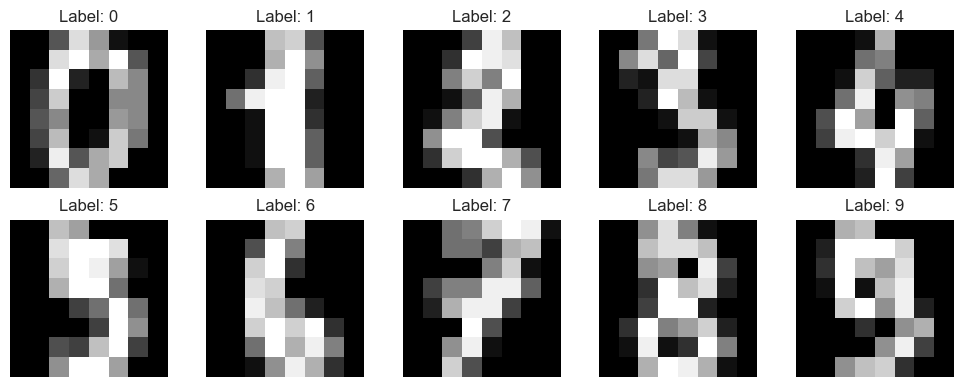

In [181]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [182]:
sample_idx = 0
print("One image as an 8x8 matrix:")
display(pd.DataFrame(digits.images[sample_idx]))

print("The same image flattened into a vector of 64 features:")
print(digits.data[sample_idx])

One image as an 8x8 matrix:


,0,1,2,3,4,5,6,7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0
1,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0
2,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0
3,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0
4,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0
5,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0
6,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0
7,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0


The same image flattened into a vector of 64 features:
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


# Image features: deeply learned representations

Images also need to be turned into numerical features before a model can use them.

At the simplest level, an image is just a grid of pixel values.  
But raw pixels are often not the most useful representation.

In classical computer vision, people often designed features by hand.  
In modern AI, especially in deep learning, the model learns useful image features automatically.

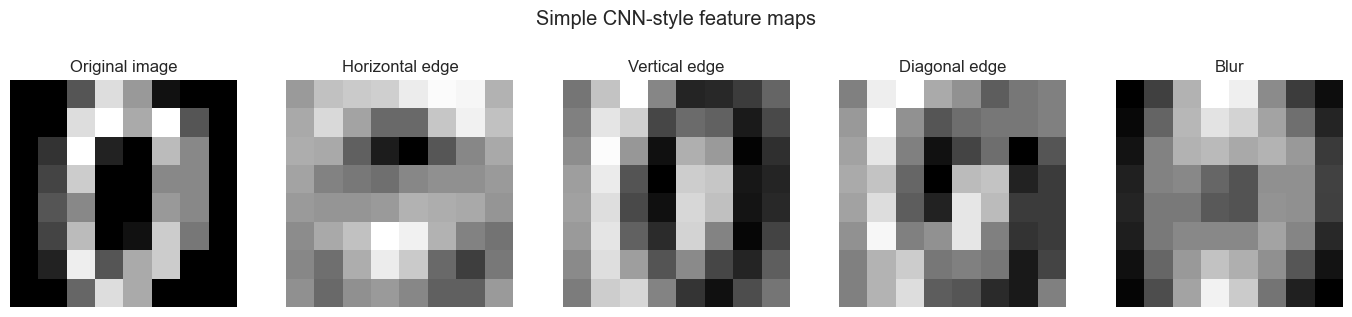

In [191]:
from scipy.signal import convolve2d

# Load a simple image from the digits dataset
digits = load_digits()
img = digits.images[0]

# Define a few simple filters
filters = {
    "Horizontal edge": np.array([[1, 1, 1],
                                 [0, 0, 0],
                                 [-1, -1, -1]]),

    "Vertical edge": np.array([[1, 0, -1],
                               [1, 0, -1],
                               [1, 0, -1]]),

    "Diagonal edge": np.array([[ 1,  0,  0],
                               [ 0,  0,  0],
                               [ 0,  0, -1]]),

    "Blur": np.ones((3, 3)) / 9
}

# Plot original image and feature maps
fig, axes = plt.subplots(1, len(filters) + 1, figsize=(14, 3))

# Original image
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

# Filtered images (feature maps)
for ax, (name, kernel) in zip(axes[1:], filters.items()):
    feature_map = convolve2d(img, kernel, mode="same", boundary="symm")
    ax.imshow(feature_map, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Simple CNN-style feature maps", y=1.05)
plt.tight_layout()
plt.show()

# Missing data and imputation

Real-world datasets often contain missing values.

Many models cannot handle missing values directly, so we need to preprocess them.

In [184]:
from numpy import nan

X_missing = np.array([
    [nan, 0,   3],
    [3,   7,   9],
    [3,   5,   2],
    [4,   nan, 6],
    [8,   8,   1]
])
X_missing

array([[nan,  0.,  3.],
       [ 3.,  7.,  9.],
       [ 3.,  5.,  2.],
       [ 4., nan,  6.],
       [ 8.,  8.,  1.]])

## Imputation

A simple strategy is to replace missing values with the column mean.

In [185]:
imp = SimpleImputer(strategy="mean")
X_imputed = imp.fit_transform(X_missing)
X_imputed

array([[4.5, 0. , 3. ],
       [3. , 7. , 9. ],
       [3. , 5. , 2. ],
       [4. , 5. , 6. ],
       [8. , 8. , 1. ]])

In [186]:
y_reg = np.array([14, 16, -1, 8, -5])
model = LinearRegression().fit(X_imputed, y_reg)
model.predict(X_imputed)

array([13.14869292, 14.3784627 , -1.15539732, 10.96606197, -5.33782027])

### Teaching takeaway

Feature engineering is not only about adding new features.

It also includes **cleaning and preparing** the data so that models can use it properly.

# Pipelines

In practice, feature engineering and modelling are often combined into a **pipeline**.

This keeps the workflow tidy and makes it easier to apply the same steps consistently.

In [187]:
model = make_pipeline(
    SimpleImputer(strategy="mean"),
    PolynomialFeatures(degree=2),
    LinearRegression()
)

model.fit(X_missing, y_reg)
model.predict(X_missing)

array([14., 16., -1.,  8., -5.])

This pipeline performs:
1. imputation
2. feature expansion
3. regression

So feature engineering and modelling become one coherent workflow.

# Final summary

## What is feature engineering?
Feature engineering means **transforming raw data into useful numerical features** for a model.

## Why do we do it?
Because raw data is often:
- non-numerical
- messy
- incomplete
- not in the right representation for learning

## How do we do it?
Examples from today:
- **categorical data** → one-hot encoding
- **text** → Bag of Words, TF-IDF, embeddings
- **images** → pixels or extracted features
- **numbers** → scaling and derived features
- **missing data** → imputation
- **workflows** → pipelines

---

## Most important takeaway

> Feature engineering has not disappeared in the age of AI.

In many modern systems, it has evolved into **representation learning**.

So the main idea remains:

> **better representation often leads to better learning**